#### **Задание #3**

Выполнил: Мирасов Константин Владимирович

ИСУ: 466716

Группа: J3212

#### Импортируем библиотеки, объявляем необходимые константы и вспомогательные функции

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn import metrics
from sklearn.cluster import DBSCAN, KMeans

In [30]:
DATA_PATH: Path = Path("../data/train_stations_europe.csv")
EARTH_RADIUS_KILOMETERS: float = 6371.0088
RANDOM_STATE: int = 42

GLOBAL_DBSCAN_EPS_KILOMETERS: float = 20.0
GLOBAL_DBSCAN_MIN_SAMPLES: int = 30

SELECTED_COUNTRY_CODE: str = "SE"
KMEANS_CLUSTER_COUNT: int = 4

COUNTRY_DBSCAN_EPS_KILOMETERS: float = 35.0
COUNTRY_DBSCAN_MIN_SAMPLES: int = 50

In [31]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

#### Загрузка и первичный анализ данных

Перед кластеризацией сначала загружаем CSV-файл и проверяем его базовую структуру. На этом этапе важно понять размер датасета, посмотреть первые строки, проверить типы колонок, оценить количество пропусков и убедиться, что в данных есть географические координаты `latitude` и `longitude`, которые будут использоваться для кластеризации станций

In [32]:
station_data = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Размер датасета: {station_data.shape[0]} строк, {station_data.shape[1]} колонок")

display(station_data.head())

print("Типы колонок:")
display(station_data.dtypes)

missing_values_by_column = station_data.isna().sum()

print("Пропуски по колонкам:")
display(missing_values_by_column)

print(f"Количество стран: {station_data['country'].nunique()}")

valid_coordinates_mask = station_data["latitude"].notna() & station_data["longitude"].notna()
station_data_with_coordinates = station_data[valid_coordinates_mask].copy()

print(f"Строк с валидными координатами: {len(station_data_with_coordinates)}")
print(f"Строк без координат: {(~valid_coordinates_mask).sum()}")

Размер датасета: 70524 строк, 18 колонок


,id,name,name_norm,uic,latitude,longitude,parent_station_id,country,time_zone,is_city,is_main_station,is_airport,entur_id,entur_is_enabled,trenord_id,cercanias_id,cercanias_hub_id,cercanias_is_enabled
0,1,Château-Arnoux – St-Auban,Chateau-Arnoux - St-Auban,NaN,44.0818,6.0016,NaN,FR,Europe/Paris,True,False,False,NaN,False,NaN,NaN,NaN,False
1,2,Château-Arnoux – St-Auban,Chateau-Arnoux - St-Auban,8775123.0000,44.0616,5.9974,1.0000,FR,Europe/Paris,False,True,False,NaN,False,NaN,NaN,NaN,False
2,3,Château-Arnoux Mairie,Chateau-Arnoux Mairie,8775122.0000,44.0639,6.0112,1.0000,FR,Europe/Paris,False,False,False,NaN,False,NaN,NaN,NaN,False
3,4,Digne-les-Bains,Digne-les-Bains,NaN,44.3500,6.3500,NaN,FR,Europe/Paris,True,False,False,NaN,False,NaN,NaN,NaN,False
4,6,Digne-les-Bains,Digne-les-Bains,8775149.0000,44.0887,6.2230,4.0000,FR,Europe/Paris,False,True,False,NaN,False,NaN,NaN,NaN,False


Типы колонок:


id                        int64
name                        str
name_norm                   str
uic                     float64
latitude                float64
longitude               float64
parent_station_id       float64
country                     str
time_zone                   str
is_city                    bool
is_main_station            bool
is_airport                 bool
entur_id                    str
entur_is_enabled           bool
trenord_id              float64
cercanias_id            float64
cercanias_hub_id        float64
cercanias_is_enabled       bool
dtype: object

Пропуски по колонкам:


id                          0
name                        1
name_norm                   1
uic                     46788
latitude                 1831
longitude                1831
parent_station_id       65229
country                     0
time_zone                   0
is_city                     0
is_main_station             0
is_airport                  0
entur_id                69888
entur_is_enabled            0
trenord_id              70524
cercanias_id            70524
cercanias_hub_id        70524
cercanias_is_enabled        0
dtype: int64

Количество стран: 43
Строк с валидными координатами: 68693
Строк без координат: 1831


После загрузки видно, что всего в датасете **70 524 строки**. Из них **68 693 строки** содержат валидные значения `latitude` и `longitude`, а **1 831 строка** не имеет координат

Так как дальнейшая кластеризация строится на географическом расстоянии между станциями, для неё будем использовать только строки с валидными координатами, сохранённые в переменной `station_data_with_coordinates`

#### Подготовка координат и вспомогательные функции

Для кластеризации всех станций Европы алгоритмом DBSCAN будем использовать Haversine-метрику, потому что она считает расстояние между точками по широте и долготе на поверхности Земли. В `sklearn` при `metric="haversine"` координаты должны быть переданы в радианах, поэтому значения `latitude` и `longitude` нужно заранее перевести из градусов в радианы

Параметр `eps` в DBSCAN задаётся в тех же единицах, в которых считаются расстояния. Поэтому выбранное расстояние в километрах нужно перевести в радианы: для этого делим расстояние на радиус Земли

Для анализа отдельной страны удобнее использовать простую проекцию координат в километры. На небольшой территории такая проекция достаточно наглядна: координаты можно интерпретировать как расстояния по осям в километрах, а затем использовать алгоритмы и метрики, работающие с обычным евклидовым расстоянием

In [33]:
def convert_kilometers_to_radians(distance_kilometers: float) -> float:
    return distance_kilometers / EARTH_RADIUS_KILOMETERS


def count_clusters(cluster_labels: np.ndarray) -> int:
    labels_without_noise = cluster_labels[cluster_labels != -1]
    unique_cluster_labels = np.unique(labels_without_noise)
    return int(len(unique_cluster_labels))


def calculate_coverage(cluster_labels: np.ndarray) -> float:
    if len(cluster_labels) == 0:
        return 0.0

    clustered_objects_count = np.count_nonzero(cluster_labels != -1)
    return float(clustered_objects_count / len(cluster_labels))


def summarize_clustering(cluster_labels: np.ndarray) -> dict[str, float | int]:
    total_objects_count = len(cluster_labels)
    noise_objects_count = int(np.count_nonzero(cluster_labels == -1))
    clustered_objects_count = int(total_objects_count - noise_objects_count)

    return {
        "clusters_count": count_clusters(cluster_labels),
        "coverage": calculate_coverage(cluster_labels),
        "clustered_objects_count": clustered_objects_count,
        "noise_objects_count": noise_objects_count,
        "total_objects_count": int(total_objects_count),
    }


def project_coordinates_to_kilometers(
    latitude_values: pd.Series,
    longitude_values: pd.Series,
) -> np.ndarray:
    latitude_values_radians = np.radians(latitude_values.to_numpy())
    longitude_values_radians = np.radians(longitude_values.to_numpy())

    latitude_center_radians = float(np.mean(latitude_values_radians))
    longitude_center_radians = float(np.mean(longitude_values_radians))

    x_coordinates_kilometers = (
        EARTH_RADIUS_KILOMETERS
        * (longitude_values_radians - longitude_center_radians)
        * np.cos(latitude_center_radians)
    )
    y_coordinates_kilometers = EARTH_RADIUS_KILOMETERS * (
        latitude_values_radians - latitude_center_radians
    )

    return np.column_stack((x_coordinates_kilometers, y_coordinates_kilometers))


coordinates_radians = np.radians(
    station_data_with_coordinates[["latitude", "longitude"]].to_numpy()
)

#### Подбор параметров DBSCAN для всех станций Европы

Для DBSCAN по всем станциям Европы переберём несколько заранее заданных комбинаций `eps` и `min_samples`

Целимся в покрытие примерно **70-80%** объектов кластерами. Если `eps` слишком маленький, соседних станций будет недостаточно для формирования плотных областей, поэтому алгоритм пометит много объектов как шум. Если `eps` слишком большой, DBSCAN начнёт склеивать почти все плотные регионы в крупные кластеры, и результат станет менее интерпретируемым

In [34]:
target_coverage = 0.75

dbscan_parameter_combinations = [
    (10, 10.0),
    (12, 12.0),
    (15, 12.0),
    (20, 15.0),
    (30, 20.0),
]

dbscan_parameter_search_rows = []

for min_samples, eps_kilometers in dbscan_parameter_combinations:
    dbscan_model = DBSCAN(
        eps=convert_kilometers_to_radians(eps_kilometers),
        min_samples=min_samples,
        metric="haversine",
        algorithm="ball_tree",
    )
    cluster_labels = dbscan_model.fit_predict(coordinates_radians)

    noise_count = int(np.count_nonzero(cluster_labels == -1))
    coverage = calculate_coverage(cluster_labels)
    clusters_count = count_clusters(cluster_labels)

    dbscan_parameter_search_rows.append(
        {
            "min_samples": min_samples,
            "eps_kilometers": eps_kilometers,
            "clusters_count": clusters_count,
            "coverage": coverage,
            "noise_count": noise_count,
        }
    )

dbscan_parameter_search_results = (
    pd.DataFrame(dbscan_parameter_search_rows)
    .assign(coverage_distance_to_target=lambda dataframe: (dataframe["coverage"] - target_coverage).abs())
    .sort_values("coverage_distance_to_target")
    .drop(columns="coverage_distance_to_target")
    .reset_index(drop=True)
)

display(dbscan_parameter_search_results)

,min_samples,eps_kilometers,clusters_count,coverage,noise_count
0,20,15.0000,197,0.7574,16665
1,15,12.0000,271,0.7359,18140
2,10,10.0000,424,0.7652,16128
3,30,20.0000,106,0.7722,15648
4,12,12.0000,331,0.7887,14512


По результатам перебора фиксируем параметры для дальнейшей кластеризации всех станций Европы:

- `eps = 20.0` км
- `min_samples = 30`

Эта комбинация даёт около **77.22%** покрытия и **106 кластеров**, то есть попадает в требуемый диапазон 70-80% и при этом не создаёт чрезмерно большое число кластеров

#### Финальная кластеризация DBSCAN по всей Европе

Используем выбранные ранее параметры DBSCAN для финальной кластеризации всех станций Европы: `eps = 20.0` км и `min_samples = 30`

Метрика `metric="haversine"` выбрана потому, что мы работаем с географическими координатами: широтой и долготой. Haversine-расстояние учитывает форму поверхности Земли и поэтому подходит для измерения расстояний между станциями по координатам

В `sklearn` при использовании `metric="haversine"` координаты и радиус поиска должны быть заданы в радианах. Поэтому `eps = 20` км переводится в радианы с помощью функции `convert_kilometers_to_radians(GLOBAL_DBSCAN_EPS_KILOMETERS)`

In [35]:
global_dbscan_model = DBSCAN(
    eps=convert_kilometers_to_radians(GLOBAL_DBSCAN_EPS_KILOMETERS),
    min_samples=GLOBAL_DBSCAN_MIN_SAMPLES,
    metric="haversine",
    algorithm="ball_tree",
)

global_cluster_labels = global_dbscan_model.fit_predict(coordinates_radians)

station_data_with_global_clusters = station_data_with_coordinates.copy()
station_data_with_global_clusters["global_cluster"] = global_cluster_labels

global_clustering_summary = summarize_clustering(global_cluster_labels)
display(pd.Series(global_clustering_summary, name="value"))

global_clusters_count = count_clusters(global_cluster_labels)
global_coverage = calculate_coverage(global_cluster_labels)
global_noise_count = int(np.count_nonzero(global_cluster_labels == -1))

print(f"Число кластеров: {global_clusters_count}")
print(f"coverage: {global_coverage:.4f}")
print(f"noise_count: {global_noise_count}")

clusters_count              106.0000
coverage                      0.7722
clustered_objects_count   53045.0000
noise_objects_count       15648.0000
total_objects_count       68693.0000
Name: value, dtype: float64

Число кластеров: 106
coverage: 0.7722
noise_count: 15648


#### Визуализация кластеров DBSCAN на карте Европы

Визуализация строится по исходным географическим координатам: по оси X используется `longitude`, а по оси Y — `latitude`. Цветом показывается номер кластера `global_cluster`, полученный после применения DBSCAN ко всем станциям Европы

Шумовые точки, для которых `global_cluster == -1`, отображаются отдельным слоем. Это позволяет визуально отделить станции, которые алгоритм не смог отнести ни к одному плотному кластеру

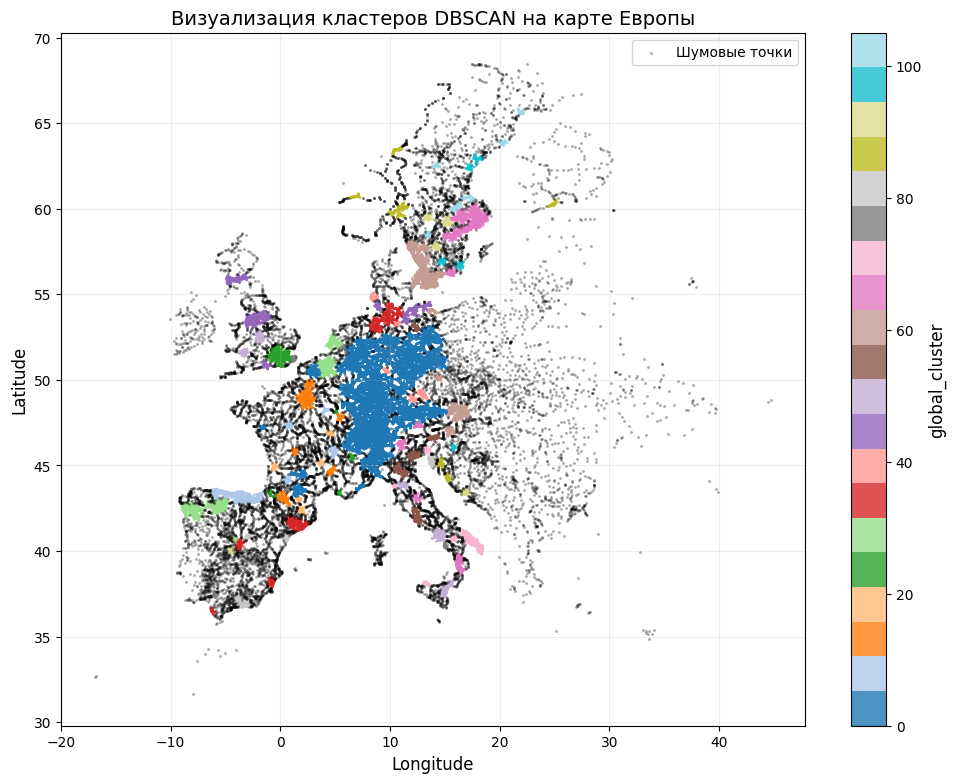

In [36]:
non_noise_stations = station_data_with_global_clusters[
    station_data_with_global_clusters["global_cluster"] != -1
]
noise_stations = station_data_with_global_clusters[
    station_data_with_global_clusters["global_cluster"] == -1
]

plt.figure(figsize=(12, 9))

cluster_scatter = plt.scatter(
    non_noise_stations["longitude"],
    non_noise_stations["latitude"],
    c=non_noise_stations["global_cluster"],
    s=4,
    cmap="tab20",
    alpha=0.8,
    linewidths=0,
)

plt.scatter(
    noise_stations["longitude"],
    noise_stations["latitude"],
    c="black",
    s=4,
    alpha=0.35,
    label="Шумовые точки",
    linewidths=0,
)

plt.title("Визуализация кластеров DBSCAN на карте Европы")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.2)
plt.legend()

colorbar = plt.colorbar(cluster_scatter)
colorbar.set_label("global_cluster")

plt.show()

#### Анализ покрытия и шума по странам

После применения DBSCAN важно дополнительно оценить результат не только в целом по всем данным, но и в разрезе отдельных стран. Такой анализ показывает, какие страны хорошо покрываются найденными кластерами, а где значительная часть станций остаётся шумом

Это особенно важно для географических данных: DBSCAN чувствителен к плотности объектов. Поэтому страны с плотной железнодорожной сетью чаще попадают в кластеры, а территории с более разреженным распределением станций могут давать большую долю шумовых объектов

In [37]:
country_cluster_coverage = (
    station_data_with_global_clusters
    .groupby("country")
    .agg(
        total_objects=("global_cluster", "size"),
        clustered_objects=("global_cluster", lambda cluster_labels: int((cluster_labels != -1).sum())),
        noise_objects=("global_cluster", lambda cluster_labels: int((cluster_labels == -1).sum())),
    )
    .assign(
        coverage_share=lambda dataframe: dataframe["clustered_objects"] / dataframe["total_objects"],
        noise_share=lambda dataframe: dataframe["noise_objects"] / dataframe["total_objects"],
    )
    .sort_values("total_objects", ascending=False)
)

top_coverage_countries = (
    country_cluster_coverage
    .query("total_objects >= 100")
    .sort_values(["coverage_share", "total_objects"], ascending=[False, False])
    .head(10)
)

top_noise_count_countries = (
    country_cluster_coverage
    .sort_values(["noise_objects", "noise_share"], ascending=[False, False])
    .head(10)
)

top_noise_share_countries = (
    country_cluster_coverage
    .query("total_objects >= 100")
    .sort_values(["noise_share", "noise_objects"], ascending=[False, False])
    .head(10)
)

print("1. Страны с total_objects >= 100 и максимальным coverage_share:")
display(top_coverage_countries)

print("2. Страны с максимальным noise_objects:")
display(top_noise_count_countries)

print("3. Страны с total_objects >= 100 и максимальным noise_share:")
display(top_noise_share_countries)

1. Страны с total_objects >= 100 и максимальным coverage_share:


,total_objects,clustered_objects,noise_objects,coverage_share,noise_share
country,,,,,
CH,22266,22266,0,1.0000,0.0000
DE,13741,13157,584,0.9575,0.0425
BE,574,505,69,0.8798,0.1202
AT,1542,1261,281,0.8178,0.1822
SE,5767,4089,1678,0.7090,0.2910
GB,2766,1837,929,0.6641,0.3359
IT,4947,3072,1875,0.6210,0.3790
NL,446,257,189,0.5762,0.4238
FR,6340,3295,3045,0.5197,0.4803


2. Страны с максимальным noise_objects:


,total_objects,clustered_objects,noise_objects,coverage_share,noise_share
country,,,,,
FR,6340,3295,3045,0.5197,0.4803
ES,5189,2242,2947,0.4321,0.5679
IT,4947,3072,1875,0.6210,0.3790
SE,5767,4089,1678,0.7090,0.2910
GB,2766,1837,929,0.6641,0.3359
DE,13741,13157,584,0.9575,0.0425
PL,531,19,512,0.0358,0.9642
NO,856,346,510,0.4042,0.5958
HR,730,283,447,0.3877,0.6123


3. Страны с total_objects >= 100 и максимальным noise_share:


,total_objects,clustered_objects,noise_objects,coverage_share,noise_share
country,,,,,
UA,215,0,215,0.0000,1.0000
BG,187,0,187,0.0000,1.0000
RO,152,0,152,0.0000,1.0000
IE,142,0,142,0.0000,1.0000
RS,109,0,109,0.0000,1.0000
HU,200,5,195,0.0250,0.9750
PT,172,5,167,0.0291,0.9709
BA,131,4,127,0.0305,0.9695
PL,531,19,512,0.0358,0.9642


По таблице `top_coverage_countries` видно, что лучше всего кластерами DBSCAN покрываются страны с высокой плотностью железнодорожных станций: **CH**, **DE**, **BE**, **AT**, **SE**. В этих странах станции расположены достаточно компактно, поэтому при выбранных параметрах `eps = 20` км и `min_samples = 30` алгоритм уверенно объединяет большую часть объектов в плотные области

По абсолютному числу шумовых объектов лидируют **FR**, **ES**, **IT**, **SE**, **GB**: это крупные страны с большим количеством станций, поэтому даже умеренная доля шума даёт большой абсолютный объём. При этом таблица `top_noise_share_countries` показывает другой эффект: у ряда стран с менее плотным или более разреженным распределением станций почти все объекты становятся шумом. Это ожидаемое поведение DBSCAN, поскольку алгоритм ищет области достаточной локальной плотности и хуже покрывает территории, где станции расположены редко или вытянуто вдоль отдельных линий

#### Выбор страны для детальной кластеризации

Для детальной кластеризации выбрана страна **Швеция**

Швеция подходит для отдельного анализа по нескольким причинам:

1. объектов достаточно много — **5767**
2. страна имеет вытянутую географию
3. кластеры удобно интерпретировать визуально
4. K-Means и DBSCAN дают сравнимое число кластеров

Страна: SE
Число объектов: 5767
Диапазон latitude: 55.3442 ... 68.4411
Диапазон longitude: 11.0097 ... 24.1381


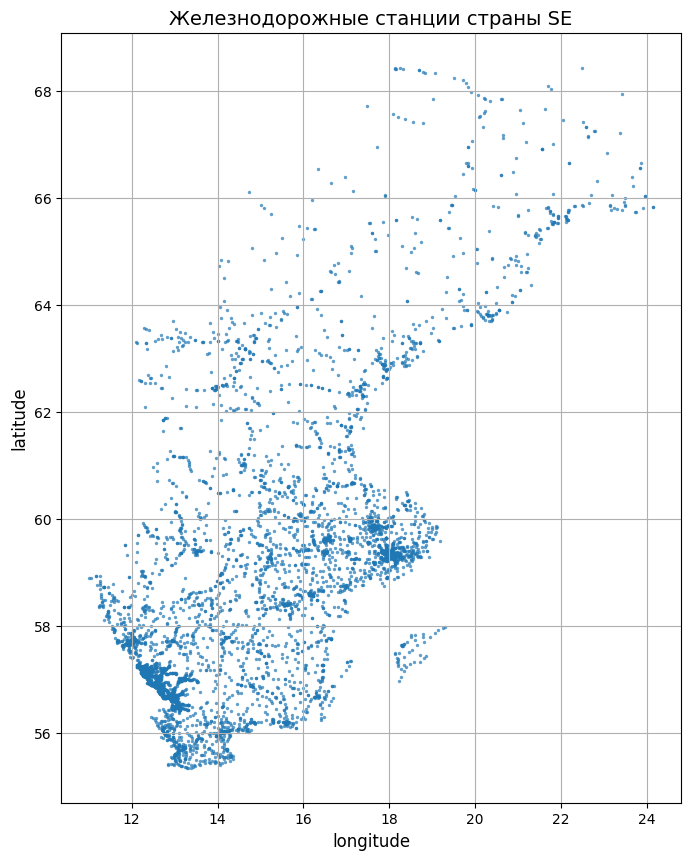

In [38]:
selected_country_data = station_data_with_global_clusters[
    station_data_with_global_clusters["country"] == SELECTED_COUNTRY_CODE
].copy()

selected_country_objects_count = len(selected_country_data)

print(f"Страна: {SELECTED_COUNTRY_CODE}")
print(f"Число объектов: {selected_country_objects_count}")

latitude_min = selected_country_data["latitude"].min()
latitude_max = selected_country_data["latitude"].max()
longitude_min = selected_country_data["longitude"].min()
longitude_max = selected_country_data["longitude"].max()

print(f"Диапазон latitude: {latitude_min:.4f} ... {latitude_max:.4f}")
print(f"Диапазон longitude: {longitude_min:.4f} ... {longitude_max:.4f}")

selected_country_coordinates_kilometers = project_coordinates_to_kilometers(
    selected_country_data["latitude"],
    selected_country_data["longitude"],
)

plt.figure(figsize=(8, 10))
plt.scatter(
    selected_country_data["longitude"],
    selected_country_data["latitude"],
    s=6,
    alpha=0.7,
    linewidths=0,
)
plt.title(f"Железнодорожные станции страны {SELECTED_COUNTRY_CODE}")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

#### Подбор числа кластеров K-Means методом локтя

Алгоритм K-Means требует заранее заданное число кластеров `k`: модель не определяет его автоматически, а только распределяет объекты между уже заданным количеством центроидов. Поэтому перед финальным обучением K-Means нужно подобрать разумное значение `k`

Для подбора используем **метод локтя**: обучаем K-Means при разных значениях `k` и смотрим, как меняется `inertia` — сумма квадратов расстояний объектов до ближайших центроидов. Пока увеличение числа кластеров сильно уменьшает `inertia`, модель становится заметно лучше. После точки «локтя» дополнительное увеличение `k` даёт уже меньший выигрыш

Дополнительно для проверки качества посчитаем `silhouette_score`: эта метрика показывает, насколько объекты похожи на свой кластер по сравнению с соседними кластерами. Чем выше значение, тем лучше выражено разделение кластеров

Для K-Means используем координаты станций выбранной страны в километрах, а не исходные широту и долготу в градусах. Это важно, потому что K-Means работает с евклидовым расстоянием, и градусы широты/долготы не являются одинаковыми единицами расстояния по двум осям

,k,inertia,silhouette_score
0,2,239956326.2952,0.5368
1,3,112427626.1801,0.5712
2,4,80302019.6838,0.5679
3,5,65522170.7596,0.4716
4,6,55061411.0015,0.3991
5,7,46095077.8215,0.4331
6,8,40503820.0770,0.4225
7,9,35011342.5730,0.4556
8,10,30854098.8415,0.4707
9,11,27581058.8697,0.4737


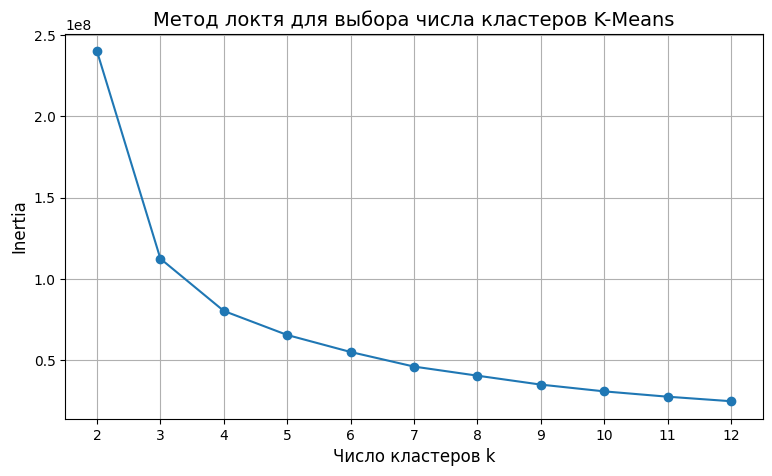

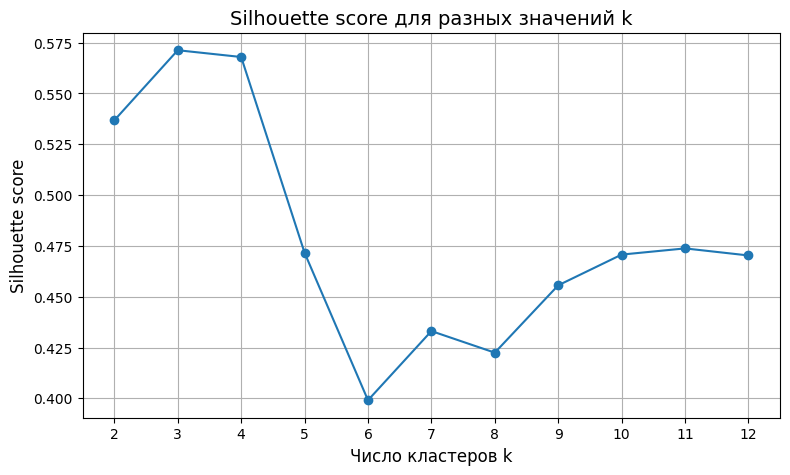

In [39]:
k_values = list(range(2, 13))
kmeans_inertia_values = []
kmeans_silhouette_scores = []

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    kmeans_cluster_labels = kmeans_model.fit_predict(selected_country_coordinates_kilometers)

    kmeans_inertia_values.append(float(kmeans_model.inertia_))
    kmeans_silhouette_scores.append(
        float(
            metrics.silhouette_score(
                selected_country_coordinates_kilometers,
                kmeans_cluster_labels,
            )
        )
    )

kmeans_selection_table = pd.DataFrame(
    {
        "k": k_values,
        "inertia": kmeans_inertia_values,
        "silhouette_score": kmeans_silhouette_scores,
    }
)

display(kmeans_selection_table)

plt.figure(figsize=(9, 5))
plt.plot(
    kmeans_selection_table["k"],
    kmeans_selection_table["inertia"],
    marker="o",
)
plt.title("Метод локтя для выбора числа кластеров K-Means")
plt.xlabel("Число кластеров k")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    kmeans_selection_table["k"],
    kmeans_selection_table["silhouette_score"],
    marker="o",
)
plt.title("Silhouette score для разных значений k")
plt.xlabel("Число кластеров k")
plt.ylabel("Silhouette score")
plt.xticks(k_values)
plt.show()

По графику метода локтя фиксируем `KMEANS_CLUSTER_COUNT = 4`

При увеличении числа кластеров до `k = 4` значение `inertia` снижается достаточно резко, то есть дополнительные центроиды заметно улучшают компактность кластеров. После `k = 4` снижение `inertia` становится менее резким: дальнейшее увеличение числа кластеров даёт меньший выигрыш и может дробить естественные группы станций на слишком мелкие части

Значения `silhouette_score` при выбранном `k = 4` остаются хорошими, поэтому это число кластеров можно использовать для дальнейшего сравнения K-Means и DBSCAN на подвыборке выбранной страны

#### Финальная кластеризация K-Means для Швеции

Теперь обучаем финальную модель K-Means с выбранным числом кластеров `k = 4`. Это значение сохранено в константе `KMEANS_CLUSTER_COUNT` и было выбрано на предыдущем шаге по методу локтя: оно даёт достаточно компактные группы станций без чрезмерного дробления данных

In [40]:
final_kmeans_model = KMeans(
    n_clusters=KMEANS_CLUSTER_COUNT,
    random_state=RANDOM_STATE,
    n_init=20,
)

kmeans_cluster_labels = final_kmeans_model.fit_predict(
    selected_country_coordinates_kilometers
)

selected_country_data["kmeans_cluster"] = kmeans_cluster_labels

kmeans_cluster_sizes = (
    selected_country_data["kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("kmeans_cluster")
    .reset_index(name="stations_count")
)

display(kmeans_cluster_sizes)

kmeans_silhouette_score = metrics.silhouette_score(
    selected_country_coordinates_kilometers,
    kmeans_cluster_labels,
)

print(f"Silhouette score: {kmeans_silhouette_score:.4f}")

,kmeans_cluster,stations_count
0,0,614
1,1,2877
2,2,305
3,3,1971


Silhouette score: 0.5679


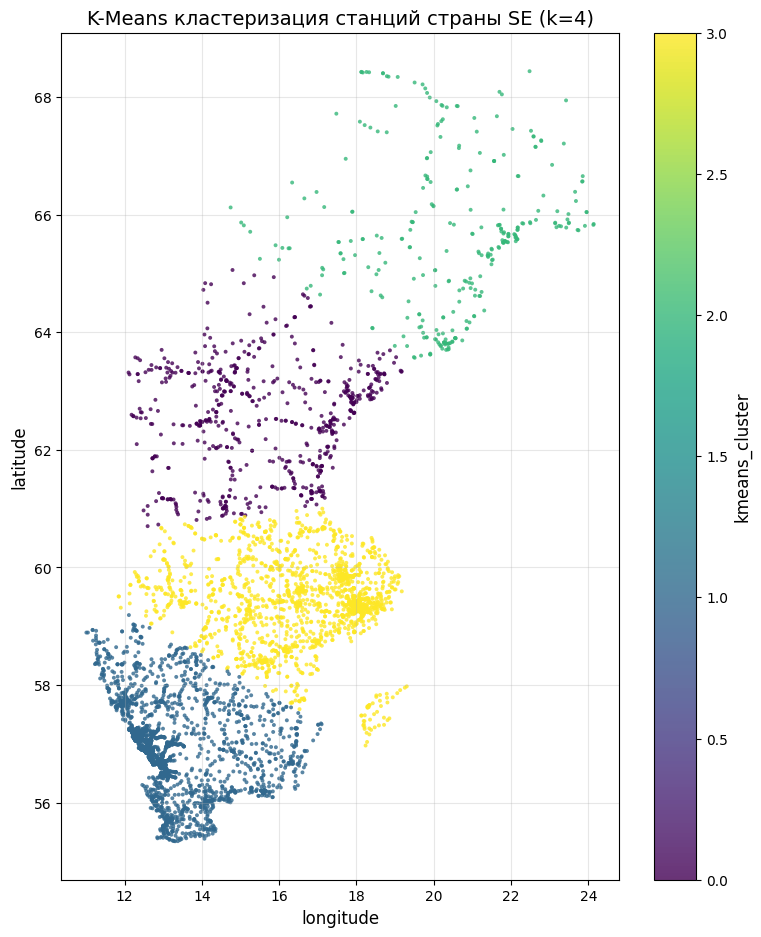

In [41]:
plt.figure(figsize=(9, 11))

scatter = plt.scatter(
    selected_country_data["longitude"],
    selected_country_data["latitude"],
    c=selected_country_data["kmeans_cluster"],
    s=8,
    alpha=0.8,
    linewidths=0,
)

plt.title(
    f"K-Means кластеризация станций страны {SELECTED_COUNTRY_CODE} "
    f"(k={KMEANS_CLUSTER_COUNT})"
)
plt.xlabel("longitude")
plt.ylabel("latitude")
colorbar = plt.colorbar(scatter)
colorbar.set_label("kmeans_cluster")
plt.grid(True, alpha=0.3)
plt.show()

K-Means с `k = 4` разбивает станции Швеции на четыре непересекающиеся группы и присваивает кластер каждому объекту подвыборки. Так как Швеция сильно вытянута по широте, на карте хорошо видно пространственное разделение станций на крупные географические зоны. Значение `silhouette_score` можно использовать как численную оценку качества этого разбиения и как базу для дальнейшего сравнения с DBSCAN

#### DBSCAN для выбранной страны

Теперь подбираем DBSCAN для Швеции. Цель — получить число кластеров, близкое к результату K-Means, то есть около `4` кластеров

В отличие от K-Means, DBSCAN не требует заранее задавать число кластеров. Вместо этого он ищет плотные группы точек по параметрам `eps` и `min_samples`. Поэтому DBSCAN может не только выделять кластеры, но и оставлять часть разреженных станций как шумовые объекты с меткой `-1`

In [42]:
country_dbscan_model = DBSCAN(
    eps=COUNTRY_DBSCAN_EPS_KILOMETERS,
    min_samples=COUNTRY_DBSCAN_MIN_SAMPLES,
    metric="euclidean",
    algorithm="ball_tree",
)

country_dbscan_cluster_labels = country_dbscan_model.fit_predict(
    selected_country_coordinates_kilometers
)

selected_country_data["dbscan_cluster"] = country_dbscan_cluster_labels

country_dbscan_summary = {
    "clusters_count": count_clusters(country_dbscan_cluster_labels),
    "coverage": calculate_coverage(country_dbscan_cluster_labels),
    "noise_count": int(np.count_nonzero(country_dbscan_cluster_labels == -1)),
}

country_dbscan_cluster_sizes = (
    selected_country_data.loc[
        selected_country_data["dbscan_cluster"] != -1,
        "dbscan_cluster",
    ]
    .value_counts()
    .sort_index()
    .rename_axis("dbscan_cluster")
    .reset_index(name="stations_count")
)

display(pd.Series(country_dbscan_summary, name="value"))
display(country_dbscan_cluster_sizes)

print(f"Число кластеров без шума: {country_dbscan_summary['clusters_count']}")
print(f"coverage: {country_dbscan_summary['coverage']:.4f}")
print(f"noise_count: {country_dbscan_summary['noise_count']}")

clusters_count     4.0000
coverage           0.8304
noise_count      978.0000
Name: value, dtype: float64

,dbscan_cluster,stations_count
0,0,2859
1,1,1698
2,2,102
3,3,130


Число кластеров без шума: 4
coverage: 0.8304
noise_count: 978


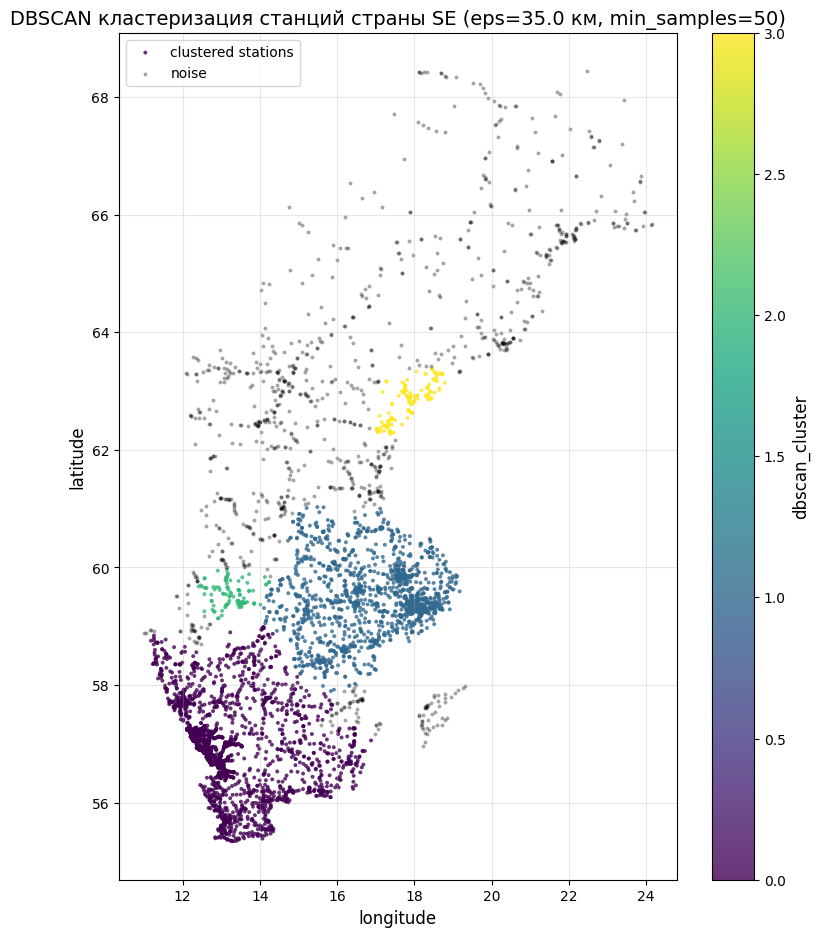

In [43]:
country_dbscan_clustered_data = selected_country_data[
    selected_country_data["dbscan_cluster"] != -1
]

country_dbscan_noise_data = selected_country_data[
    selected_country_data["dbscan_cluster"] == -1
]

plt.figure(figsize=(9, 11))

scatter = plt.scatter(
    country_dbscan_clustered_data["longitude"],
    country_dbscan_clustered_data["latitude"],
    c=country_dbscan_clustered_data["dbscan_cluster"],
    s=8,
    alpha=0.8,
    linewidths=0,
    label="clustered stations",
)

plt.scatter(
    country_dbscan_noise_data["longitude"],
    country_dbscan_noise_data["latitude"],
    c="black",
    s=8,
    alpha=0.35,
    linewidths=0,
    label="noise",
)

plt.title(
    f"DBSCAN кластеризация станций страны {SELECTED_COUNTRY_CODE} "
    f"(eps={COUNTRY_DBSCAN_EPS_KILOMETERS} км, "
    f"min_samples={COUNTRY_DBSCAN_MIN_SAMPLES})"
)
plt.xlabel("longitude")
plt.ylabel("latitude")
colorbar = plt.colorbar(scatter)
colorbar.set_label("dbscan_cluster")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

DBSCAN получил число кластеров, близкое к K-Means: при выбранных параметрах выделено `4` плотных кластера. При этом алгоритм не относит все станции к кластерам: часть разреженных станций остаётся шумом

В результате покрытие составляет примерно `83.04%`, а шумовых объектов — `978`. Это показывает ключевое отличие DBSCAN от K-Means: DBSCAN лучше отделяет плотные группы станций, но не пытается принудительно распределить редкие и удалённые точки по ближайшим кластерам

#### Визуальное сравнение результатов

Рядом сравним две карты кластеризации для выбранной страны: слева показан результат K-Means, а справа — результат DBSCAN

K-Means распределяет все станции по регионам: каждая станция обязательно получает номер одного из кластеров. Поэтому на карте K-Means нет шумовых объектов, даже если некоторые станции расположены далеко от основной плотной группы

DBSCAN работает иначе: он выделяет плотные области и оставляет часть объектов шумом. Поэтому на карте DBSCAN кластеризованные станции показаны цветом, а шумовые станции вынесены отдельным слоем

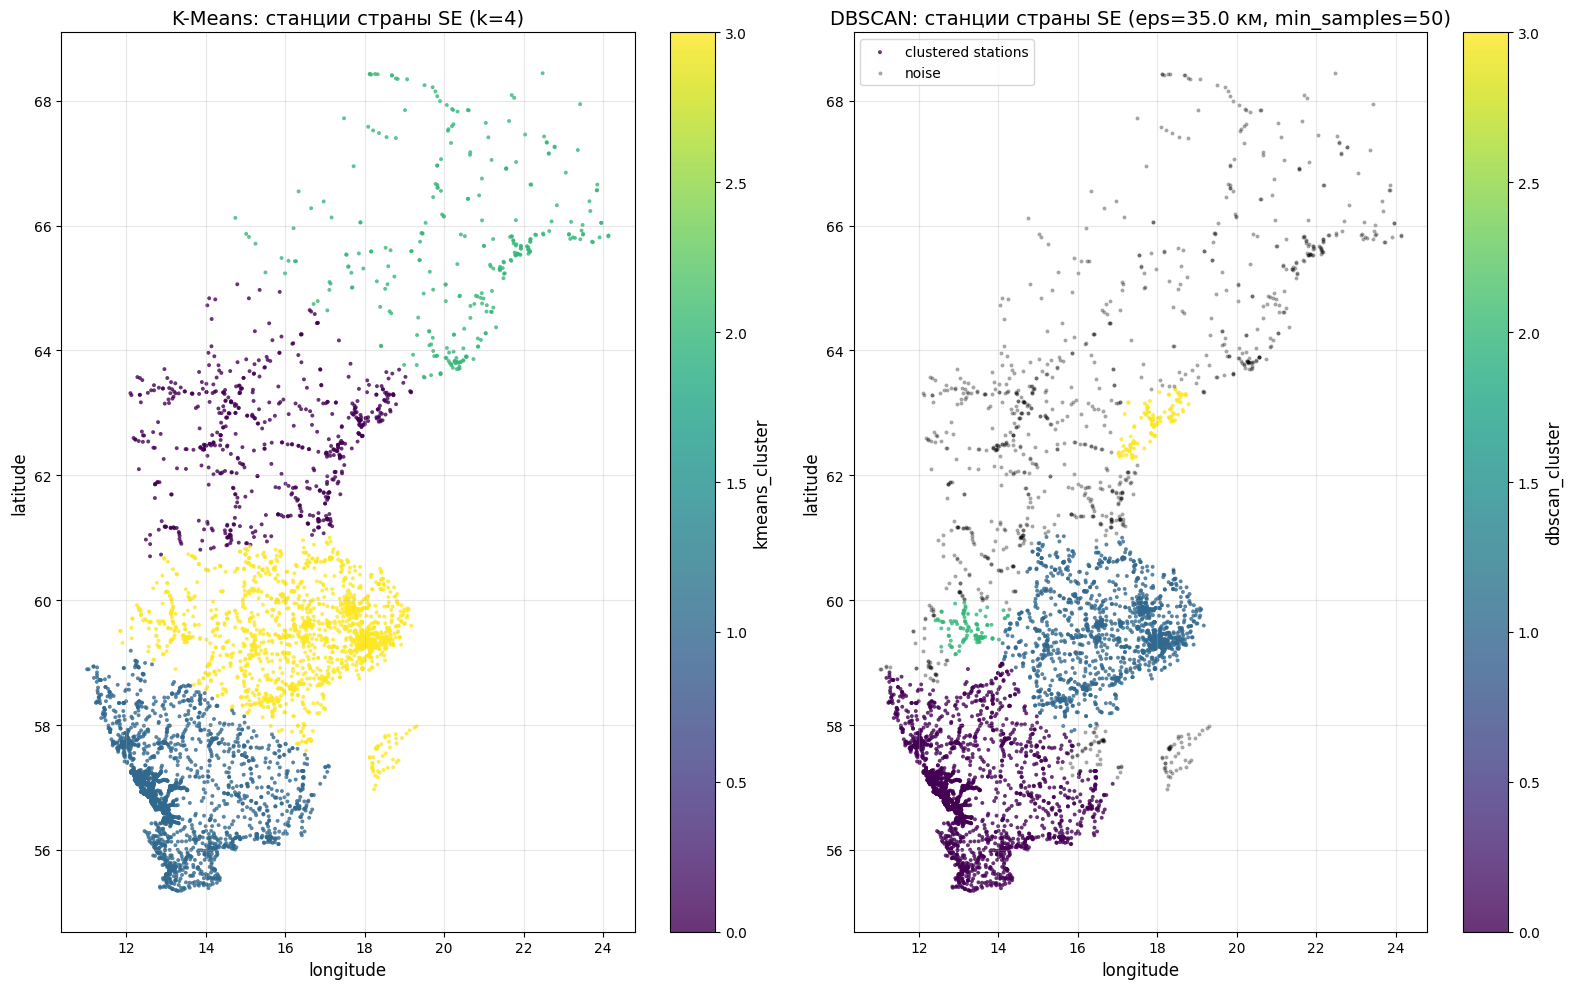

In [44]:
kmeans_plot_data = selected_country_data.copy()

dbscan_clustered_stations = selected_country_data[
    selected_country_data["dbscan_cluster"] != -1
]
dbscan_noise_stations = selected_country_data[
    selected_country_data["dbscan_cluster"] == -1
]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

kmeans_scatter = axes[0].scatter(
    kmeans_plot_data["longitude"],
    kmeans_plot_data["latitude"],
    c=kmeans_plot_data["kmeans_cluster"],
    s=8,
    alpha=0.8,
    linewidths=0,
)

axes[0].set_title(
    f"K-Means: станции страны {SELECTED_COUNTRY_CODE} "
    f"(k={KMEANS_CLUSTER_COUNT})"
)
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")
axes[0].grid(True, alpha=0.3)

kmeans_colorbar = fig.colorbar(kmeans_scatter, ax=axes[0])
kmeans_colorbar.set_label("kmeans_cluster")

dbscan_scatter = axes[1].scatter(
    dbscan_clustered_stations["longitude"],
    dbscan_clustered_stations["latitude"],
    c=dbscan_clustered_stations["dbscan_cluster"],
    s=8,
    alpha=0.8,
    linewidths=0,
    label="clustered stations",
)

axes[1].scatter(
    dbscan_noise_stations["longitude"],
    dbscan_noise_stations["latitude"],
    c="black",
    s=8,
    alpha=0.35,
    linewidths=0,
    label="noise",
)

axes[1].set_title(
    f"DBSCAN: станции страны {SELECTED_COUNTRY_CODE} "
    f"(eps={COUNTRY_DBSCAN_EPS_KILOMETERS} км, "
    f"min_samples={COUNTRY_DBSCAN_MIN_SAMPLES})"
)
axes[1].set_xlabel("longitude")
axes[1].set_ylabel("latitude")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

dbscan_colorbar = fig.colorbar(dbscan_scatter, ax=axes[1])
dbscan_colorbar.set_label("dbscan_cluster")

plt.tight_layout()
plt.show()

#### Сравнение K-Means и DBSCAN

Для итогового сравнения используем несколько метрик, которые показывают разные свойства кластеризации:

- **Число кластеров** — количество найденных групп без учёта шума. Для K-Means оно задаётся заранее, а для DBSCAN получается из плотности точек
- **Покрытие** — доля объектов, которым алгоритм присвоил кластер. У K-Means покрытие всегда равно `1.0`, потому что каждая точка относится к одному из кластеров. У DBSCAN покрытие меньше, так как часть точек получает label `-1` и считается шумом
- **Шум** — число и доля объектов с label `-1`. Эта метрика актуальна для DBSCAN и показывает, сколько станций алгоритм не смог отнести к плотным группам
- **Размеры кластеров** — распределение объектов по кластерам. По нему видно, насколько равномерно алгоритм разделил данные и есть ли слишком маленькие или слишком крупные группы
- **Silhouette** — метрика качества разделения кластеров: чем значение выше, тем лучше объекты похожи на свой кластер и дальше от соседних кластеров. Для DBSCAN считаем silhouette только по не шумовым объектам
- **Среднее внутрикластерное расстояние** — среднее расстояние от точек до центроида своего кластера. Чем меньше значение, тем компактнее кластеры
- **Среднее межкластерное расстояние** — среднее расстояние между центроидами разных кластеров. Чем больше значение, тем сильнее кластеры разделены между собой


In [45]:
def calculate_cluster_distance_metrics(
    coordinates: np.ndarray,
    cluster_labels: np.ndarray,
) -> dict[str, float]:
    coordinates = np.asarray(coordinates, dtype=float)
    cluster_labels = np.asarray(cluster_labels)

    if coordinates.shape[0] != cluster_labels.shape[0]:
        raise ValueError(
            "coordinates and cluster_labels must contain the same number of objects"
        )

    non_noise_mask = cluster_labels != -1
    clustered_coordinates = coordinates[non_noise_mask]
    clustered_labels = cluster_labels[non_noise_mask]
    unique_cluster_labels = np.unique(clustered_labels)

    if len(unique_cluster_labels) == 0:
        return {
            "mean_intra_cluster_distance": np.nan,
            "mean_inter_cluster_distance": np.nan,
        }

    centroids = []
    intra_cluster_distances = []

    for cluster_label in unique_cluster_labels:
        cluster_coordinates = clustered_coordinates[clustered_labels == cluster_label]
        cluster_centroid = cluster_coordinates.mean(axis=0)
        centroids.append(cluster_centroid)

        point_distances_to_centroid = np.linalg.norm(
            cluster_coordinates - cluster_centroid,
            axis=1,
        )
        intra_cluster_distances.extend(point_distances_to_centroid.tolist())

    centroids = np.vstack(centroids)
    mean_intra_cluster_distance = float(np.mean(intra_cluster_distances))

    if len(centroids) < 2:
        mean_inter_cluster_distance = np.nan
    else:
        centroid_pairwise_distances = np.linalg.norm(
            centroids[:, np.newaxis, :] - centroids[np.newaxis, :, :],
            axis=2,
        )
        upper_triangle_indices = np.triu_indices(len(centroids), k=1)
        mean_inter_cluster_distance = float(
            np.mean(centroid_pairwise_distances[upper_triangle_indices])
        )

    return {
        "mean_intra_cluster_distance": mean_intra_cluster_distance,
        "mean_inter_cluster_distance": mean_inter_cluster_distance,
    }


In [46]:
def calculate_silhouette_without_noise(
    coordinates: np.ndarray,
    cluster_labels: np.ndarray,
    chunk_size: int = 512,
) -> float:
    coordinates = np.asarray(coordinates, dtype=float)
    cluster_labels = np.asarray(cluster_labels)

    non_noise_mask = cluster_labels != -1
    clustered_coordinates = coordinates[non_noise_mask]
    clustered_labels = cluster_labels[non_noise_mask]
    unique_cluster_labels = np.unique(clustered_labels)

    if len(unique_cluster_labels) < 2 or len(clustered_coordinates) <= len(unique_cluster_labels):
        return np.nan

    cluster_coordinates_list = [
        clustered_coordinates[clustered_labels == cluster_label]
        for cluster_label in unique_cluster_labels
    ]
    silhouette_values = []

    for cluster_index, cluster_coordinates in enumerate(cluster_coordinates_list):
        cluster_size = len(cluster_coordinates)

        for start_index in range(0, cluster_size, chunk_size):
            stop_index = min(start_index + chunk_size, cluster_size)
            coordinate_chunk = cluster_coordinates[start_index:stop_index]

            own_cluster_distances = np.linalg.norm(
                coordinate_chunk[:, np.newaxis, :] - cluster_coordinates[np.newaxis, :, :],
                axis=2,
            )

            if cluster_size > 1:
                mean_own_cluster_distances = own_cluster_distances.sum(axis=1) / (cluster_size - 1)
            else:
                mean_own_cluster_distances = np.zeros(len(coordinate_chunk))

            mean_nearest_other_cluster_distances = np.full(len(coordinate_chunk), np.inf)

            for other_cluster_index, other_cluster_coordinates in enumerate(cluster_coordinates_list):
                if other_cluster_index == cluster_index:
                    continue

                other_cluster_distances = np.linalg.norm(
                    coordinate_chunk[:, np.newaxis, :] - other_cluster_coordinates[np.newaxis, :, :],
                    axis=2,
                )
                mean_nearest_other_cluster_distances = np.minimum(
                    mean_nearest_other_cluster_distances,
                    other_cluster_distances.mean(axis=1),
                )

            denominator = np.maximum(
                mean_own_cluster_distances,
                mean_nearest_other_cluster_distances,
            )
            chunk_silhouette_values = np.divide(
                mean_nearest_other_cluster_distances - mean_own_cluster_distances,
                denominator,
                out=np.zeros_like(mean_own_cluster_distances),
                where=denominator > 0,
            )
            silhouette_values.extend(chunk_silhouette_values.tolist())

    return float(np.mean(silhouette_values))


def build_comparison_row(
    algorithm_name: str,
    coordinates: np.ndarray,
    cluster_labels: np.ndarray,
) -> dict[str, float | int | str]:
    cluster_labels = np.asarray(cluster_labels)
    non_noise_cluster_labels = cluster_labels[cluster_labels != -1]

    cluster_sizes = (
        pd.Series(non_noise_cluster_labels)
        .value_counts()
        .sort_index()
    )
    distance_metrics = calculate_cluster_distance_metrics(coordinates, cluster_labels)

    return {
        "algorithm": algorithm_name,
        "clusters_count": count_clusters(cluster_labels),
        "coverage": calculate_coverage(cluster_labels),
        "noise_objects": int(np.count_nonzero(cluster_labels == -1)),
        "noise_share": float(np.mean(cluster_labels == -1)),
        "cluster_sizes": ", ".join(str(size) for size in cluster_sizes.tolist()),
        "min_cluster_size": int(cluster_sizes.min()),
        "mean_cluster_size": float(cluster_sizes.mean()),
        "max_cluster_size": int(cluster_sizes.max()),
        "silhouette": calculate_silhouette_without_noise(coordinates, cluster_labels),
        "mean_intra_cluster_distance_km": distance_metrics["mean_intra_cluster_distance"],
        "mean_inter_cluster_distance_km": distance_metrics["mean_inter_cluster_distance"],
    }


comparison_table = pd.DataFrame(
    [
        build_comparison_row(
            "K-Means",
            selected_country_coordinates_kilometers,
            kmeans_cluster_labels,
        ),
        build_comparison_row(
            "DBSCAN",
            selected_country_coordinates_kilometers,
            country_dbscan_cluster_labels,
        ),
    ]
).set_index("algorithm")

comparison_table_display = comparison_table.copy()
comparison_table_display[
    [
        "coverage",
        "noise_share",
        "mean_cluster_size",
        "silhouette",
        "mean_intra_cluster_distance_km",
        "mean_inter_cluster_distance_km",
    ]
] = comparison_table_display[
    [
        "coverage",
        "noise_share",
        "mean_cluster_size",
        "silhouette",
        "mean_intra_cluster_distance_km",
        "mean_inter_cluster_distance_km",
    ]
].round(4)

display(comparison_table_display)


,clusters_count,coverage,noise_objects,noise_share,cluster_sizes,min_cluster_size,mean_cluster_size,max_cluster_size,silhouette,mean_intra_cluster_distance_km,mean_inter_cluster_distance_km
algorithm,,,,,,,,,,,
K-Means,4,1.0000,0,0.0000,"614, 2877, 305, 1971",305,1441.7500,2877,0.5679,102.8346,590.7079
DBSCAN,4,0.8304,978,0.1696,"2859, 1698, 102, 130",102,1197.2500,2859,0.5083,84.0514,396.8509


#### Интерпретация сравнения

Оба алгоритма в итоговой настройке выделяют **4 кластера**, но делают это по-разному

**K-Means** покрывает все объекты выбранной страны: `coverage = 1.0`, шумовых точек нет. Его silhouette получается около `0.568`, то есть немного выше, чем у DBSCAN. Это означает, что при принудительном разбиении всех станций на четыре группы кластеры в среднем хорошо отделяются друг от друга. Однако среднее внутрикластерное расстояние у K-Means выше: алгоритм обязан отнести кластерам даже удалённые и периферийные станции, поэтому кластеры становятся менее компактными

**DBSCAN** тоже находит 4 кластера, но покрывает примерно `83%` объектов, а остальные станции относит к шуму. Silhouette для DBSCAN считаем только по не шумовым объектам; он получается около `0.508`. Значение ниже, чем у K-Means, зато среднее внутрикластерное расстояние меньше: DBSCAN формирует более плотные кластеры и не пытается насильно включать в них разреженные точки. Это хорошо отражает плотностную природу алгоритма

Итог: если нужна полная кластеризация всех станций выбранной страны и более простое разделение пространства на крупные области, лучше подходит **K-Means**. Если важнее выделить именно плотные группы станций и отдельно показать разреженные или удалённые станции как шум, то полезнее **DBSCAN**. В рамках этого задания DBSCAN хорошо выполняет требование по покрытию не менее 70-80%, но K-Means даёт более полное и немного более стабильное разбиение для выбранной страны

## Выводы

В первой части работы для кластеризации всех железнодорожных станций Европы был применён DBSCAN с Haversine-метрикой, так как данные представлены географическими координатами. При параметрах `eps = 20` км и `min_samples = 30` алгоритм выделил `106` кластеров и покрыл примерно `77.22%` объектов. Это соответствует требуемому диапазону покрытия. Результаты показывают, что страны с более плотной железнодорожной сетью, например `CH` и `DE`, покрываются лучше. В странах с более разреженным или неоднородным распределением станций алгоритм чаще относит объекты к шуму

Во второй части была рассмотрена Швеция (`SE`), для которой в выборке содержится `5767` объектов. Метод локтя для K-Means показал, что разумным числом кластеров является `k = 4`. Для сравнения DBSCAN был настроен так, чтобы получить близкое число кластеров: при `eps = 35` км и `min_samples = 50` алгоритм также выделил `4` кластера. K-Means относит к кластерам все станции и формирует более равномерные географические регионы. DBSCAN лучше показывает плотные зоны железнодорожной сети, но часть станций определяет как шум

Таким образом, выбор алгоритма зависит от цели анализа. Если нужно разделить все станции страны на понятные регионы, лучше подходит K-Means. Если же требуется найти плотные железнодорожные агломерации и отдельно выделить выбросы, более полезен DBSCAN